# Hasil Eksperimen Awal

Notebook ini merangkum hasil seluruh model dari folder `src/`.
Urutan menjalankan notebook: `01_data_split`, `02_feature_extraction`, `03_baseline_models`,
`04_evaluation`, kemudian notebook ini.

Sebagai acuan, prediksi "selalu naik" sudah memperoleh akurasi 57,9% pada data test.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, roc_auc_score

DATA = Path("../data") if Path("../data").exists() else Path("data")  # berjalan dari folder notebook atau folder utama repo
pred = pd.read_csv(DATA / "predictions.csv", parse_dates=["date"])
MODELS = [c[6:] for c in pred.columns if c.startswith("pred::")]

## 1. Hasil pada Data Validation dan Test
- DA: persentase prediksi arah yang benar.
- F1 dan MCC: ukuran kinerja yang memberi bobot seimbang pada kelas NAIK dan TURUN.
- AUC: kemampuan membedakan hari NAIK dan TURUN (0,5 setara dengan prediksi acak).

In [2]:
rows = []
for m in MODELS:
    row = {"model": m}
    for s in ["val", "test"]:
        d = pred[pred.split == s]
        row[f"DA_{s}"] = accuracy_score(d.target, d[f"pred::{m}"])
        row[f"F1_{s}"] = f1_score(d.target, d[f"pred::{m}"], average="macro")
    d = pred[pred.split == "test"]
    row["MCC_test"] = matthews_corrcoef(d.target, d[f"pred::{m}"])
    row["AUC_test"] = roc_auc_score(d.target, d[f"score::{m}"]) if f"score::{m}" in d else None
    rows.append(row)
hasil = pd.DataFrame(rows).set_index("model")
hasil.round(3)

,DA_val,F1_val,DA_test,F1_test,MCC_test,AUC_test
model,,,,,,
Naive: Majority,0.517,0.341,0.579,0.367,0.000,NaN
Naive: Persistence,0.517,0.516,0.545,0.533,0.065,NaN
"ARIMA(2,1,0)",0.483,0.474,0.562,0.538,0.082,0.516
LR [Harga],0.506,0.504,0.517,0.513,0.031,0.527
HGB [Harga],0.523,0.520,0.500,0.498,0.005,0.538
LR [NLP],0.477,0.466,0.517,0.506,0.013,0.506
LR [Harga+NLP],0.517,0.516,0.517,0.514,0.034,0.539
HGB [Harga+NLP],0.517,0.515,0.455,0.453,-0.086,0.491
LR [Harga+NLP top-k],0.545,0.545,0.539,0.537,0.083,0.575


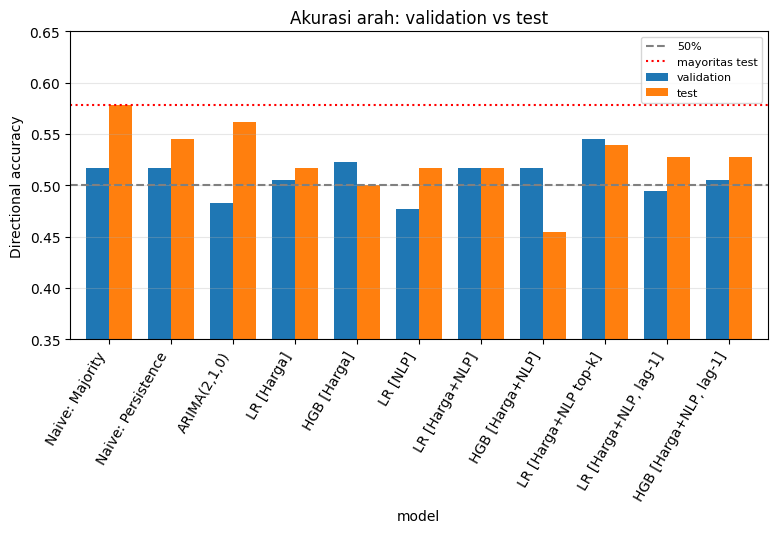

In [3]:
ax = hasil[["DA_val", "DA_test"]].plot.bar(figsize=(9, 4), width=0.75)
ax.axhline(0.5, color="gray", ls="--")
ax.axhline(pred[pred.split == "test"].target.mean(), color="red", ls=":", label="mayoritas test")
ax.set_ylim(0.35, 0.65)
ax.set_ylabel("Directional accuracy")
ax.set_title("Akurasi arah: validation vs test")
ax.legend(["50%", "mayoritas test", "validation", "test"], fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.show()

## 2. Analisis Tambahan: Stabilitas Hubungan Fitur Sentimen dengan Kurs
Tabel berikut menampilkan korelasi Spearman antara fitur sentimen dan perubahan kurs hari berikutnya
pada setiap periode. Fitur yang diperiksa adalah skor sentimen utama (VADER compound dan LM tone) serta tiga fitur
yang dipilih model top-k. Analisis ini dilakukan setelah pengujian pada data test, sehingga tidak digunakan
untuk memilih model. Tujuannya adalah memahami mengapa fitur berita belum meningkatkan kinerja model secara signifikan.

In [4]:
feat = pd.read_csv(DATA / "features.csv", parse_dates=["date"])
sp = {s: pd.read_csv(DATA / f"{s}.csv", parse_dates=["date"]).merge(feat, on="date") for s in ["train", "val", "test"]}

# Tiga fitur leksikon dengan korelasi terkuat di data train (sama dengan pilihan model top-k)
lex_cols = [c for c in feat.columns if c.startswith("lex_")]
rho = sp["train"][lex_cols].corrwith(sp["train"]["target_ret"], method="spearman").abs().sort_values(ascending=False)
fitur = ["lex_full_vader_compound", "lex_full_lm_tone"] + list(rho.index[:3])

pd.DataFrame({s: [d[c].corr(d["target_ret"], method="spearman") for c in fitur] for s, d in sp.items()},
             index=fitur).round(3)

,train,val,test
lex_full_vader_compound,-0.027,0.019,-0.012
lex_full_lm_tone,-0.009,-0.019,0.011
lex_full_vader_neu,0.075,0.045,-0.143
lex_lead_vader_pos,-0.069,0.045,-0.014
lex_title_lm_uncertainty_dev,-0.062,-0.133,-0.109


Skor sentimen utama, yaitu VADER compound dan LM tone, hampir tidak berkorelasi dengan perubahan kurs pada
seluruh periode (nilai mutlak di bawah 0,03). Dari tiga fitur pilihan top-k, dua di antaranya berubah arah korelasi
antarperiode, sehingga hubungannya tidak stabil. Hanya `lex_title_lm_uncertainty_dev`, yaitu lonjakan kata
ketidakpastian pada judul berita, yang arah korelasinya konsisten negatif pada ketiga periode.

## 3. Kesimpulan
1. Belum ada model yang mengungguli prediksi "selalu naik" (57,9%) pada data test.
2. ARIMA(2,1,0) memperoleh DA tertinggi setelah prediksi mayoritas (0,562). Model dengan fitur berita terbaik adalah
   LR top-k (DA 0,539, AUC 0,575), tetapi kedua hasil tersebut belum signifikan secara statistik.
3. Model dengan fitur berita belum terbukti lebih baik daripada model tanpa fitur berita.
4. Skor sentimen umum dari VADER dan Loughran-McDonald hampir tidak berkorelasi dengan arah kurs, sedangkan fitur
   ketidakpastian menunjukkan hubungan yang lebih konsisten meskipun lemah.
5. Rencana perbaikan selanjutnya: validasi walk-forward, penyaringan berita yang lebih ketat, penggunaan
   ambang pergerakan minimum pada target, dan penambahan data pasar (indeks dolar, suku bunga AS, dan harga minyak).